# Upper limit analysis with QuickCW samples

In this notebook we calculate upper limits based on QuickCW samples. You can either use samples from a run you did with the `running_quickcw.ipynb` notebook or you can use the samples provided based on long QuickCW runs. If you use your own run, make sure to set `amplitude_prior='UL'`. If you use the provided samples, make sure to use the one ran with the right prior (`data/15yr_quickCW_UL.h5`).

First we import the necessary packages:

In [5]:
#imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import h5py
import healpy as hp
import scipy.constants as sc
import emcee


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Then we ca read in the samples. QuickCW saves all of its results in an HDF5 file. Upon opening that file once can access:
- the samples (`samples_cold`)
- the log likelihood values corresponding to those samples (`log_likelihood`)
- the temperature ladder used for the parallel tempering (`Ts`)
- the names of parameters corresponding to each column in the samples array (`par_names`)
- the rate of different MCMC jumps being accepted (`acc_fraction`)
- the diagonal fisher matrix used for some proposals (`fisher_diag`)

In [6]:
#First we read in the hdf5 file

#hdf_file = "quickCW_test.h5"
hdf_file = "15yr_quickCW_UL.h5"

#specify how much of the first samples to discard
#(no need to discard any for provided samples as that has already been done)
#and how much more to thin the samples in addition to what we already thinned when we saved the samples
#burnin = 100_000
burnin = 0
extra_thin = 1

with h5py.File(hdf_file, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][0,burnin::extra_thin,:]
    log_likelihood = f['log_likelihood'][:,burnin::extra_thin]
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

A useful diagnostic is to plot the log likelihood values over the course of the run. The following cell does that. A good converged chain has likelihoods fluctuating aroudn a value with no clear evolution.

It is also useful to plot the different parameters of the model as a function of iteration number. These so called trace plots can also help diagnose if the run converged properly. Note that some of the plots from the provided samples will show big jumps in these plots. This is due to the fact that these samples were made by combining multiple runs over different frequency ranges together. To assess convergence one would need to look at those runs individually.

In the next cell we define a function that will calculate upper limits on the strain amplitude and their statistical error as a function of frequency. It does so by binning the samples in frequency and in each frequency bin, finding the 95th percentile of the amplitude samples. The error is calculated based on the autocorrelation length of the samples.

In [7]:
#define function to calculate upper limits

def get_UL_vs_freq(log10_fgws, log10_hs, f_bounds, n_bins, debug_plot=False):
    f_min = f_bounds[0]
    f_max = f_bounds[1]
    
    f_bins = np.logspace(np.log10(f_min), np.log10(f_max), n_bins+1)#100)

    f_bincenters = []
    for i in range(f_bins.size-1):
        f_bincenters.append((f_bins[i+1]+f_bins[i])/2)
    f_bincenters = np.array(f_bincenters)
    h, xedges, yedges, _ = plt.hist2d(log10_fgws, log10_hs, bins=[np.log10(f_bins), log10_h_bins])

    #make bin centers
    bincenters = []
    for i in range(xedges.size-1):
        bincenters.append((xedges[i+1]+xedges[i])/2)
    bincenters = np.array(bincenters)

    freq_idx = np.digitize(log10_fgws, xedges)

    UL_freq = np.zeros(bincenters.size)
    UL_sigma = np.zeros(bincenters.size)
    for i in range(bincenters.size):

        hs = 10**log10_hs[np.where(freq_idx==i+1)]
        if hs.size==0:
            UL_freq[i] = 0.0
            continue

        #normal UL
        UL_freq[i] = np.percentile(hs, 95)

        cc = emcee.autocorr.integrated_time(hs, c=10, quiet=True)[0]
        N_eff = hs.size/cc

        h_bins = np.linspace(0, np.max(hs), 100)
        hist, bin_edges = np.histogram(hs, bins=h_bins, density=True)
        ul_idx = np.where(UL_freq[i]<bin_edges)[0][0]-1
        UL_sigma[i] = np.sqrt(0.95*(1-0.95)/N_eff)/hist[ul_idx]

        if debug_plot:
            plt.figure(i+1)
            plt.plot(hs)
            plt.gca().axhline(UL_freq[i])
            plt.gca().axhline(UL_freq[i]+UL_sigma[i], ls='-.')
            plt.gca().axhline(UL_freq[i]-UL_sigma[i], ls='-.')
            
    return UL_freq, UL_sigma, bincenters, xedges

Now we can call the function we just defined. as it calculates upper limits, it also prints the amplitude samples in each frequency bin for diagnostic purposes, and it plots the upper limits along with a color map of the posterior density in frequency and amplitude.

In [8]:
%%time
#uniform prior
plt.rcParams.update({'font.size': 18})

burnin = 0
thin=1

log10_fgws = samples_cold[burnin::thin,3]
log10_hs = samples_cold[burnin::thin,4]


f_min = 1e-9
f_max = 3e-7

n_bins=37

UL_freq, UL_sigma, bincenters, xedges = get_UL_vs_freq(log10_fgws, log10_hs, [f_min,f_max], n_bins,
                                                       debug_plot=False)

CPU times: user 194 μs, sys: 965 μs, total: 1.16 ms
Wall time: 3.38 ms


NameError: name 'log10_h_bins' is not defined

Finally we plot the upper limits as a function of frequency. Using the provided samples this should closely follow the upper limits reported in the paper.

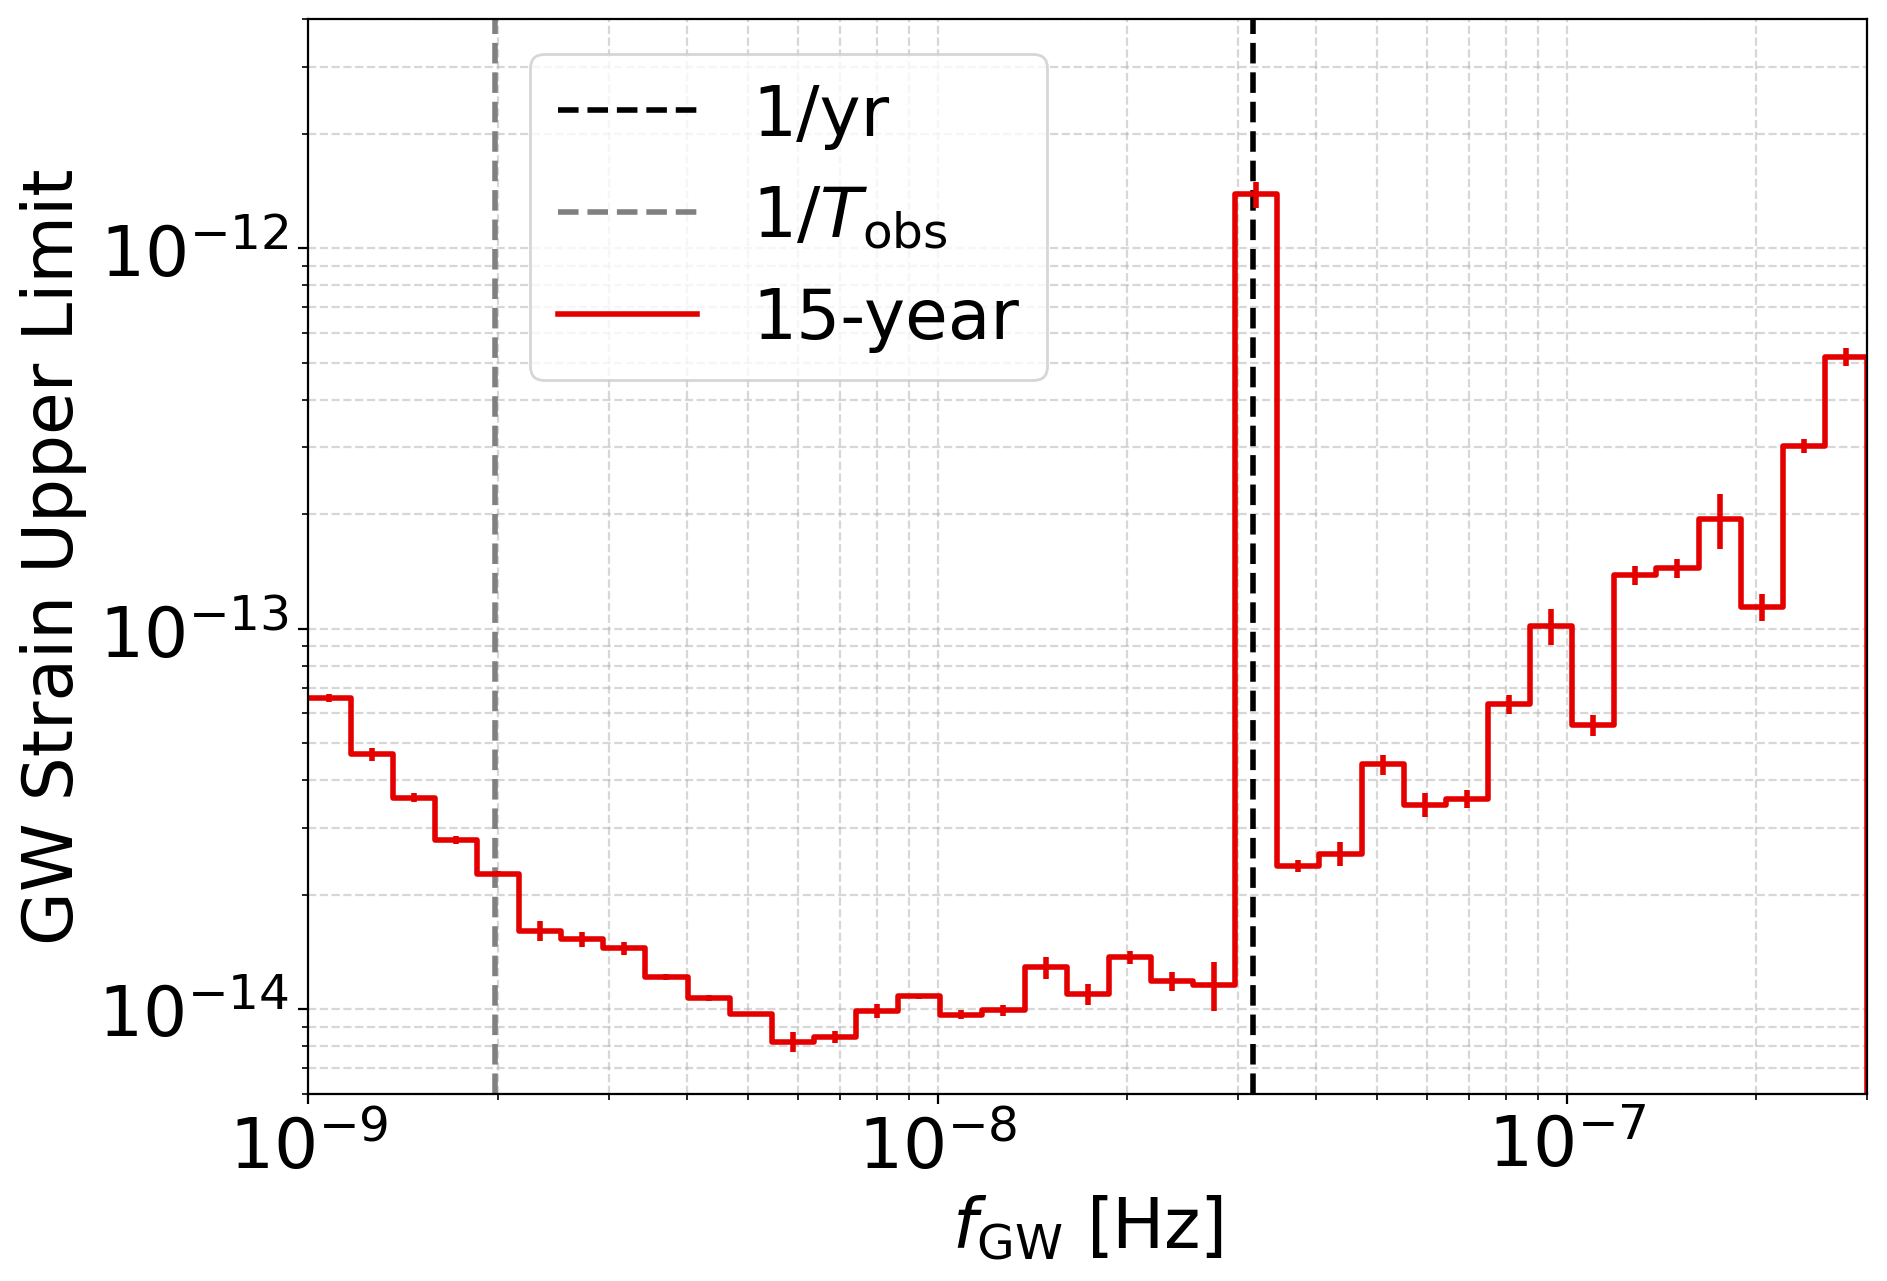

In [ ]:
matplotlib.rcParams.update({'font.size': 25})

plt.figure(figsize=(10,7))

plt.gca().axvline((365.25*86400)**-1, color='black', ls='--', lw=2, label='1/yr')
plt.gca().axvline(10**-8.704, color='gray', ls='--', lw=2, label=r'$1/T_{\rm obs}$')

#plt.errorbar(10**bincenters, UL_freq, yerr=UL_freq_error,
#             ls='', lw=2, marker='', alpha=1.0, color="xkcd:red")

plt.errorbar(10**bincenters, UL_freq, yerr=UL_sigma,
             ls='', lw=2, marker='', alpha=1.0, color="xkcd:red")

#print(xedges)
#print(len(xedges))
#print(UL_freq)
#print(UL_freq_reweight)
#print(UL_freq_error)


plt.step(10**xedges, np.concatenate((UL_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")

plt.xscale('log')
plt.yscale('log')
plt.ylim(6e-15,4e-12)
plt.xlim(1e-9, 3e-7)
plt.xlabel(r"$f_{\rm GW}$ [Hz]")
#plt.ylabel(r"$A_{\rm e}$")
plt.ylabel(r"GW Strain Upper Limit")

#plt.gca().axvline(10**(-7.6))

plt.legend(bbox_to_anchor=(0.12,1), loc="upper left")
#plt.legend(loc="upper right")
plt.grid(which='both', linestyle='--', alpha=0.5)

plt.tight_layout()